### 默认成员函数
* 第⼀：我们不写时，编译器默认⽣成的函数⾏为是什么，是否满⾜我们的需求。  
* 第⼆：编译器默认⽣成的函数不满⾜我们的需求，我们需要⾃⼰实现，那么如何⾃⼰实现？

构造函数（名字是类名）、析构函数（名字是~类名）：只有需要申请空间的，自己写  
拷贝构造：深拷贝的需要自己写，名字是类名，参数是类类型的const引用

小技巧（三法则）：  
如果显示写了析构函数，就要自己写拷贝构造和赋值运算符重载

重点区分拷贝构造和赋值运算符重载：

```cpp
// 构造
Date d1(2026, 4, 22);

// 拷贝构造
Date d2(d1);
Date d3 = d1;

// 赋值重载(针对已经有的对象赋值)
Date d4;
d4 = d1;
```

赋值重载有返回值，支持连续赋值

后置++要有一个int形参，前置++没有（C++规定）

流插入流提取运算符重载一般作为友元函数  
因为cout << d1或cin >> d1，左操作数是io流，但是如果是类的成员函数的话，第一个参数默认是this指针，不行  
不能作类的成员函数，而且还要访问类的成员变量，那就用友元函数friend  
___

### const成员函数：  
如果是const对象，则只能调用const成员函数，否则权限放大  
后面加的const实际上是把this指针修改成const Date*类型  
只要不修改成员变量的都可以加上const

### 取地址运算符重载  
也是默认成员函数的一部分  
```cpp
Date* operator&()
{
    return this;
}

const Date* operator&()const
{
    return this;
}
```
这里有两个重载，编译器都自动生成，不用自己实现

___
### 初始化列表：
```cpp
Date(int year = 1, int month = 1, int day = 1)
    :_year(year)
    ,_month(month)
    ,_day(day)
{}
```
`注意：const成员变量、引用成员、没有默认构造函数的自定义类型成员 只能在初始化列表中初始化`  
初始化列表被认为是成员变量定义的时候  
初始化列表中成员变量的初始化顺序是按照声明的顺序初始化，与初始化列表的顺序无关

___
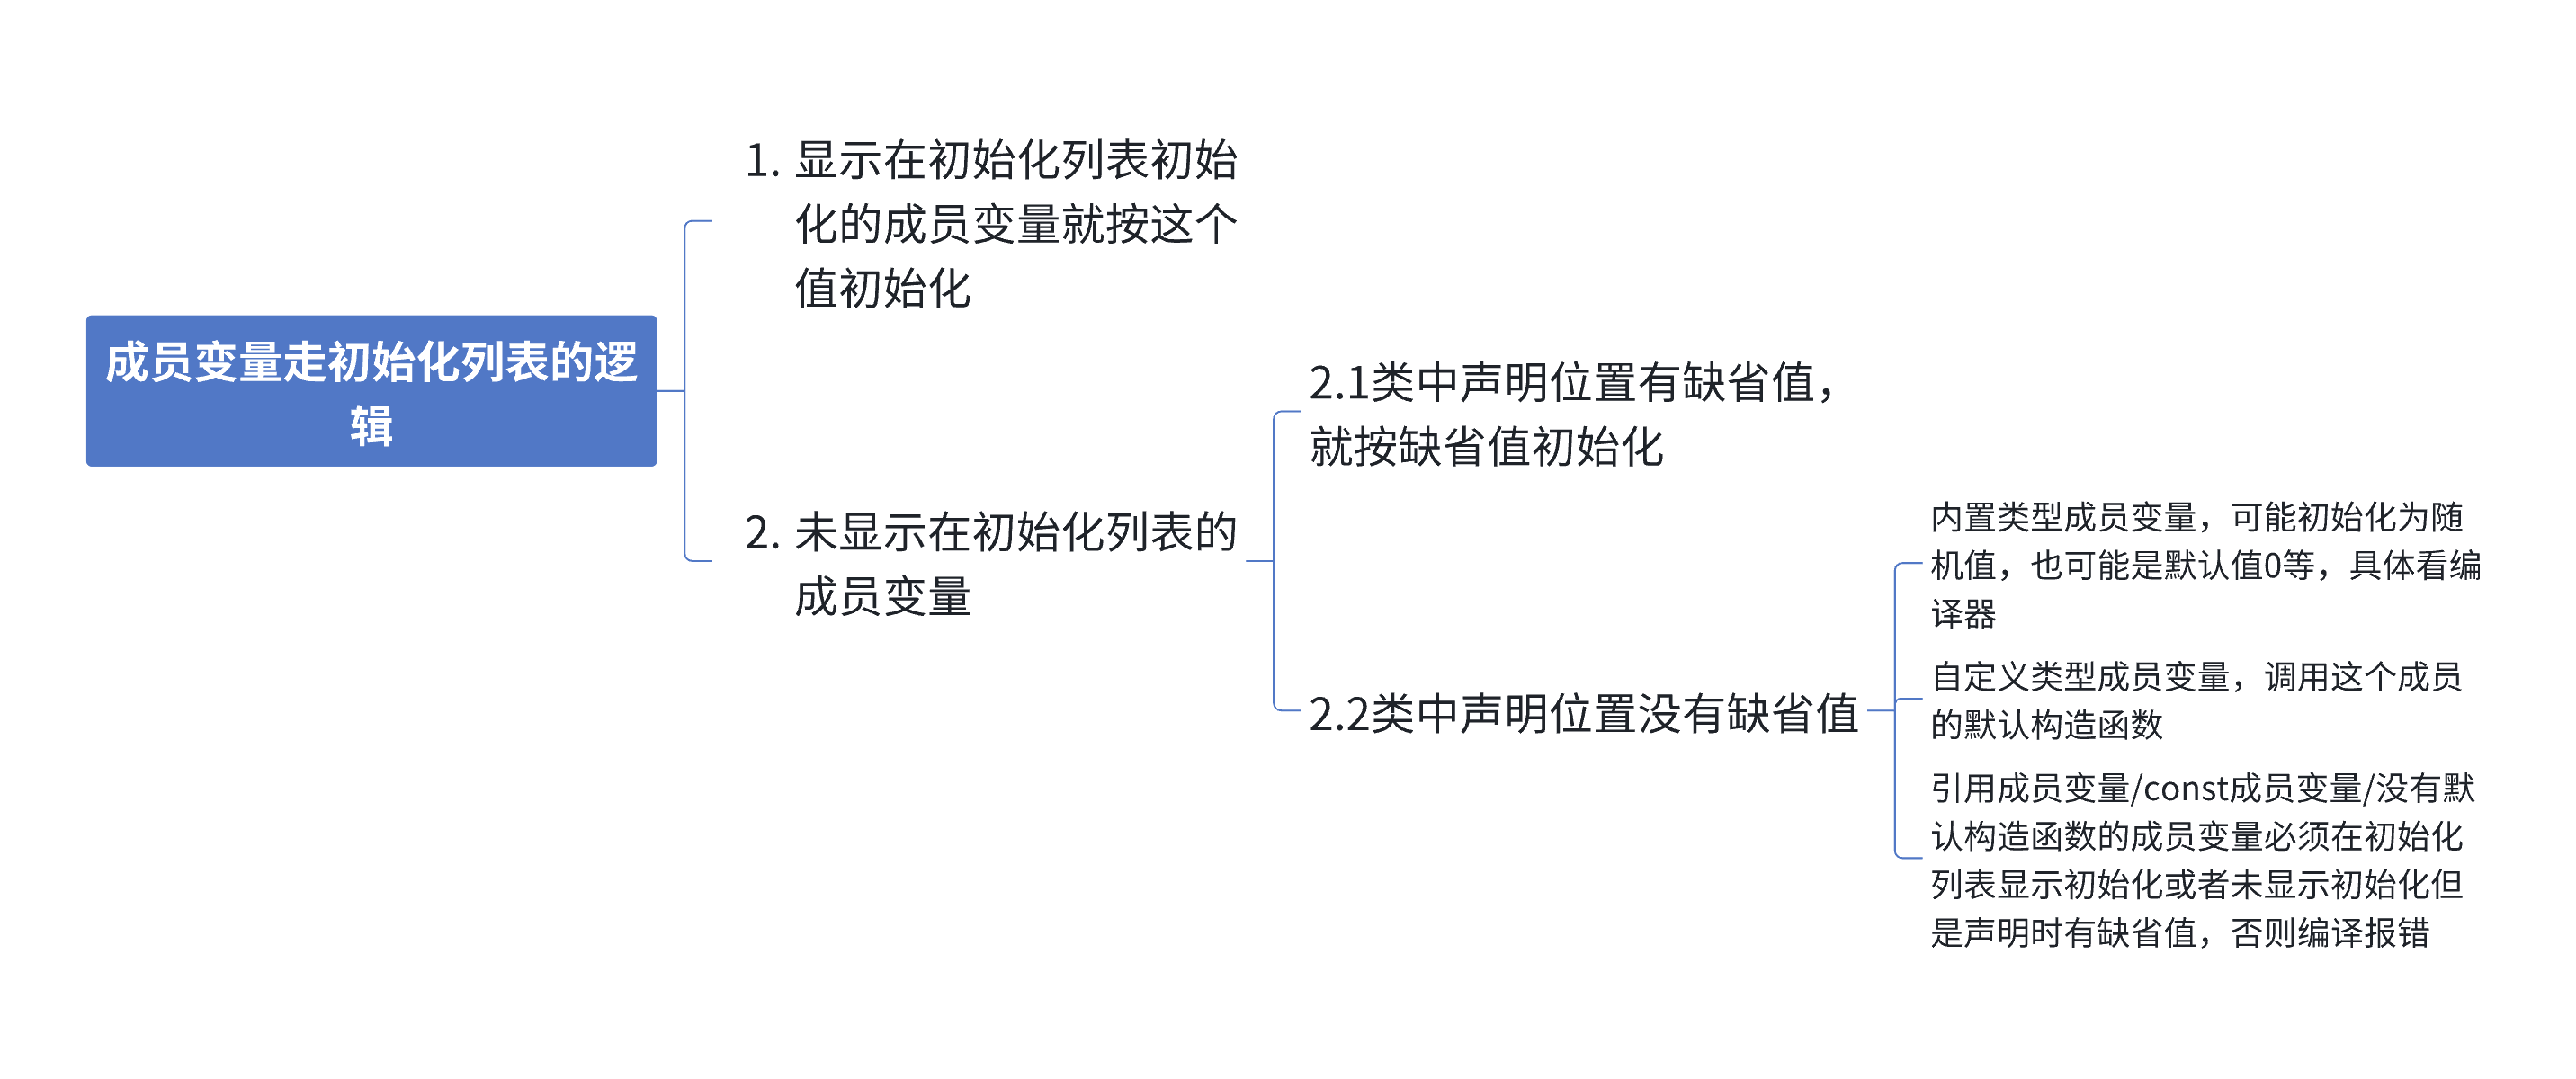

___

### static成员变量
不走初始化列表，必须在类外初始化
```cpp
// 类内声明
static int _scount;
// 类外初始化
int A::_scount = 0;
```

static成员的生命周期是全局，但是访问受类域限制（作用域还是当前类域，这与全局变量不同）  
如果类外想访问私有的static成员变量，需要static成员函数（因为无this指针，只能访问静态成员，不能访问非静态成员）

`补充：static全局变量的特点`  
只能在当前cpp文件中使用该变量

___
### 友元  
不可交换、不可传递

___
### 内部类
+ 是独立的类，与全局定义的类的区别在于访问受类域（::）和限定符（private）限制，但是空间不在外部类里面  
+ 内部类默认是外部类的友元类。

___
### 匿名对象
生命周期只在当前一行  
```cpp
#include <algorithm>

class A
{
public:
    int GetNum(int n)
    {
        return n;
    }
}

bool CmpInt(int a, int b)
{
    return a > b;
}

int main()
{
    // 有名对象
    A a1;
    // 匿名对象
    A();
    // 应用1：只是想调一下类里面的函数
    A().GetNum(10);
    // 应用2：sort排序
    int a[] = {4,5,6,7,8,1,2,3};
    // 默认升序
    sort(a, a + 8);
    // 降序写法1
    sort(a, a + 8, CmpInt);
    // 降序写法2（用了一个匿名对象）
    sort(a, a + 8, greater<int>());

    return 0;
}

```